## BERT Fine-Tuning

This notebook showcases BERT fine-tuning with a grid-search hyperparameter sweep. This setup is identical to the notebook used for fine-tuning FinBERT on the PhaseBank dataset in order to make a fair comparison between performances.

The grid-search finds the optimal hyperparameters and assesses model performance on the validation set to determine which configurations should be used for the final predictions on the test set. 

The learning rates also spans from the set `{1e-5, 2e-5, 5e-5}` and `3 to 5 epochs.`

In [18]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('financial-sentiment-comparison'):
        !git clone https://github.com/maximusrome/financial-sentiment-comparison.git
    %cd financial-sentiment-comparison
    !pip install -q transformers==4.44.2 pandas scikit-learn pyarrow matplotlib seaborn

from pathlib import Path
repo_root = Path.cwd()
if repo_root.name == "notebooks":
  repo_root = repo_root.parent
if str(repo_root) not in sys.path:
  sys.path.insert(0, str(repo_root))
print("cwd:", os.getcwd())
print("repo_root:", repo_root)
print("sys.path[0:5]:", sys.path[:5])
from evaluation import evaluate_predictions
import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

cwd: /Users/avikapursrinivasan/financial-sentiment-comparison/notebooks
repo_root: /Users/avikapursrinivasan/financial-sentiment-comparison
sys.path[0:5]: ['/Users/avikapursrinivasan/financial-sentiment-comparison', '/Users/avikapursrinivasan/financial-sentiment-comparison/notebooks', '/Users/avikapursrinivasan/miniconda3/envs/cs4120/lib/python314.zip', '/Users/avikapursrinivasan/miniconda3/envs/cs4120/lib/python3.14', '/Users/avikapursrinivasan/miniconda3/envs/cs4120/lib/python3.14/lib-dynload']
GPU: CPU only


## Load Data

In [2]:
from data_loader import build_and_save_split, load_split, SPLIT_PATH
if not SPLIT_PATH.exists():
    build_and_save_split()

## Run Sweep

In [3]:
from finbert_train import run_sweep

sweep_df = run_sweep(
    model_name='google-bert/bert-base-uncased',
    output_name='bert_finetuned',
    learning_rates=[1e-5, 2e-5, 5e-5],
    num_epochs_list=[3, 4],
    batch_size=16,
    seed=42,
    sweep_results_path="results/tables/bert_sweep.csv"
)


=== Sweep: lr=1e-05, epochs=3 ===
Device: cuda
Config: TrainConfig(model_name='google-bert/bert-base-uncased', output_name='bert_finetuned_lr1e-05_ep3', max_length=128, batch_size=16, learning_rate=1e-05, num_epochs=3, weight_decay=0.01, warmup_ratio=0.1, seed=42, predictions_path='predictions/sweep/bert_finetuned_lr1e-05_ep3.csv', metrics_path='results/tables/sweep/bert_finetuned_lr1e-05_ep3.json', model_save_dir=None)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Epoch 1/3: train_loss=0.5732  val_acc=0.8326  val_macro_f1=0.8020
  Epoch 2/3: train_loss=0.2836  val_acc=0.8450  val_macro_f1=0.8203
  Epoch 3/3: train_loss=0.1117  val_acc=0.8326  val_macro_f1=0.8156

Best epoch: 2  Val macro-F1: 0.8203
Test accuracy:  0.8202
Test macro-F1:  0.7928
Elapsed: 296.9s
Saved predictions to predictions/sweep/bert_finetuned_lr5e-05_ep3.csv
Saved metrics to results/tables/sweep/bert_finetuned_lr5e-05_ep3.json

=== Sweep: lr=5e-05, epochs=4 ===
Device: cuda
Config: TrainConfig(model_name='google-bert/bert-base-uncased', output_name='bert_finetuned_lr5e-05_ep4', max_length=128, batch_size=16, learning_rate=5e-05, num_epochs=4, weight_decay=0.01, warmup_ratio=0.1, seed=42, predictions_path='predictions/sweep/bert_finetuned_lr5e-05_ep4.csv', metrics_path='results/tables/sweep/bert_finetuned_lr5e-05_ep4.json', model_save_dir=None)


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/4: train_loss=0.5981  val_acc=0.8388  val_macro_f1=0.8063
  Epoch 2/4: train_loss=0.2969  val_acc=0.8533  val_macro_f1=0.8269
  Epoch 3/4: train_loss=0.1242  val_acc=0.8409  val_macro_f1=0.8211
  Epoch 4/4: train_loss=0.0412  val_acc=0.8306  val_macro_f1=0.8113

Best epoch: 2  Val macro-F1: 0.8269
Test accuracy:  0.8079
Test macro-F1:  0.7737
Elapsed: 393.7s
Saved predictions to predictions/sweep/bert_finetuned_lr5e-05_ep4.csv
Saved metrics to results/tables/sweep/bert_finetuned_lr5e-05_ep4.json

Sweep results saved to results/tables/bert_sweep.csv
 learning_rate  num_epochs  best_epoch_within_run  val_acc   val_f1  test_acc  test_f1  elapsed_s
       0.00001           4                      3 0.851240 0.835751  0.834711 0.809310      394.5
       0.00002           4                      2 0.855372 0.833699  0.832645 0.807635      394.0
       0.00002           3                      2 0.849174 0.830976  0.828512 0.801430      296.8
       0.00001           3                 

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/4: train_loss=0.7420  val_acc=0.8306  val_macro_f1=0.8065
  Epoch 2/4: train_loss=0.3673  val_acc=0.8492  val_macro_f1=0.8297
  Epoch 3/4: train_loss=0.2265  val_acc=0.8512  val_macro_f1=0.8358
  Epoch 4/4: train_loss=0.1679  val_acc=0.8471  val_macro_f1=0.8293

Best epoch: 3  Val macro-F1: 0.8358
Test accuracy:  0.8347
Test macro-F1:  0.8093
Elapsed: 394.2s
Saved predictions to predictions/bert_finetuned_predictions.csv
Saved metrics to results/tables/bert_finetuned_metrics.json


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Visualizations

In [6]:
import pandas as pd
sweep_df = pd.read_csv('results/tables/bert_sweep.csv')
sweep_df.round(4)

,learning_rate,num_epochs,best_epoch_within_run,val_acc,val_f1,test_acc,test_f1,elapsed_s
0,0.0,4,3,0.8512,0.8358,0.8347,0.8093,394.5
1,0.0,4,2,0.8554,0.8337,0.8326,0.8076,394.0
2,0.0,3,2,0.8492,0.8310,0.8285,0.8014,296.8
3,0.0,3,3,0.8471,0.8305,0.8388,0.8130,288.2
4,0.0,4,2,0.8533,0.8269,0.8079,0.7737,393.7
5,0.0,3,2,0.8450,0.8203,0.8202,0.7928,296.9


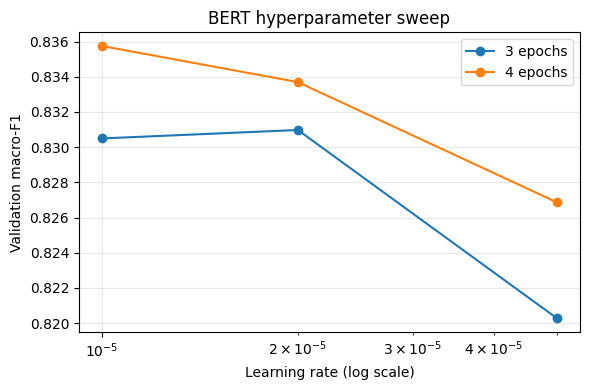

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
for n_ep, group in sweep_df.groupby('num_epochs'):
    g = group.sort_values('learning_rate')
    ax.plot(g['learning_rate'], g['val_f1'], marker='o',
            label=f'{n_ep} epochs')
ax.set_xscale('log')
ax.set_xlabel('Learning rate (log scale)')
ax.set_ylabel('Validation macro-F1')
ax.set_title('BERT hyperparameter sweep')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/bert_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Accuracy Results + F1 Score

In [17]:
from evaluation import evaluate_predictions
result = evaluate_predictions(f'{repo_root}/predictions/bert_finetuned_predictions.csv')
print(f"Test accuracy:  {result['overall']['accuracy']:.4f}")
print(f"Test macro-F1:  {result['overall']['macro_f1']:.4f}\n")
print('By agreement tier:')
for tier, m in result['by_tier'].items():
    print(f"  tier={tier:6s}  acc={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}  (n={m['n']})")

Test accuracy:  0.8347
Test macro-F1:  0.8093

By agreement tier:
  tier=100     acc=0.9602  macro_f1=0.9385  (n=226)
  tier=75-99   acc=0.8667  macro_f1=0.8167  (n=120)
  tier=66-74   acc=0.5658  macro_f1=0.5331  (n=76)
  tier=50-65   acc=0.6452  macro_f1=0.6652  (n=62)


In [ ]:
!zip -r /content/output.zip data predictions results
from google.colab import files
files.download('/content/output.zip')